# 模块 02：线性回归

## 1. 理论背景
线性回归用一条直线或超平面拟合连续目标，是理解损失函数、解析解和梯度下降的入口。这里对比正规方程与梯度下降两种求法。

## 1.1 实际作用（用途）
- 用于预测连续数值，例如房价、销售额、能耗、温度或库存需求。
- 常作为业务建模强基线，用来判断复杂模型是否真的必要。
- 帮助解释特征与目标之间的方向和强度。

## 2. 数学推导
模型为 $\hat y=Xw+b$。将偏置并入一列 1 后，记 $X_b=[1, X]$，正规方程为：

$$\theta^*=(X_b^T X_b)^{-1}X_b^T y$$

MSE 损失为 $L=\frac{1}{n}\sum_i(\hat y_i-y_i)^2$，梯度为：

$$\nabla_\theta L=\frac{2}{n}X_b^T(X_b\theta-y)$$

## 3. 代码思路

本章代码用同一批数据对比“解析求解”和“迭代优化”：

1. 先生成接近 `y = 3x + 2` 的带噪声样本，模拟真实回归数据不会完全落在直线上。
2. 给 `X` 拼接一列 1 得到 `Xb`，这样偏置 `b` 可以和斜率 `w` 一起放进参数向量 `theta`。
3. `normal_equation` 用矩阵公式一次性求出最小二乘解，作为参考答案。
4. `gradient_descent` 从全 0 参数开始，每一步计算 MSE 梯度并更新 `theta`，同时记录损失变化。
5. 验证部分比较两种方法的结果，说明梯度下降确实能逼近解析解。

## 4. NumPy 实现

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# 构造一组接近 y = 3x + 2 的带噪声数据，用来模拟真实观测误差。
rng = np.random.default_rng(42)
X = rng.uniform(-2, 2, size=(80, 1))
y = 3.0 * X[:, 0] + 2.0 + rng.normal(0, 0.25, size=80)
# 在特征矩阵最前面加一列 1，把偏置 b 合并进参数 theta。
Xb = np.c_[np.ones(len(X)), X]

def normal_equation(Xb, y):
    # pinv 是伪逆，比直接求逆更稳健；theta = (X^T X)^-1 X^T y。
    return np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y

def mse(Xb, y, theta):
    err = Xb @ theta - y
    return np.mean(err ** 2)

def gradient_descent(Xb, y, lr=0.08, steps=600):
    theta = np.zeros(Xb.shape[1])
    history = []
    for _ in range(steps):
        # MSE 对 theta 的梯度：2/n * X^T(Xtheta-y)。
        grad = (2 / len(y)) * Xb.T @ (Xb @ theta - y)
        theta -= lr * grad
        history.append(mse(Xb, y, theta))
    return theta, np.array(history)

theta_closed = normal_equation(Xb, y)
theta_gd, loss_history = gradient_descent(Xb, y)
print("正规方程解：theta =", theta_closed, "；第一项是偏置 b，第二项是斜率 w。")
print("梯度下降解：theta =", theta_gd, "；应逐步收敛到正规方程的解析解附近。")


正规方程解：theta = [1.9684 3.0291] ；第一项是偏置 b，第二项是斜率 w。
梯度下降解：theta = [1.9684 3.0291] ；应逐步收敛到正规方程的解析解附近。


## 5. 结果验证

In [3]:
# 梯度下降的数值解应该接近正规方程的解析解。
assert np.allclose(theta_closed, theta_gd, atol=1e-3)
try:
    import torch
    # 用 PyTorch 的张量运算复算正规方程，验证矩阵公式一致。
    Xt = torch.tensor(Xb, dtype=torch.float64)
    yt = torch.tensor(y, dtype=torch.float64)
    theta = torch.linalg.pinv(Xt.T @ Xt) @ Xt.T @ yt
    assert np.allclose(theta.numpy(), theta_closed, atol=1e-8)
    print("验证通过：NumPy 正规方程解与 PyTorch 最小二乘解一致。")
except ImportError:
    print("提示：当前环境未安装 PyTorch；正规方程与梯度下降结果已相互验证。")


验证通过：NumPy 正规方程解与 PyTorch 最小二乘解一致。


## 6. 可视化

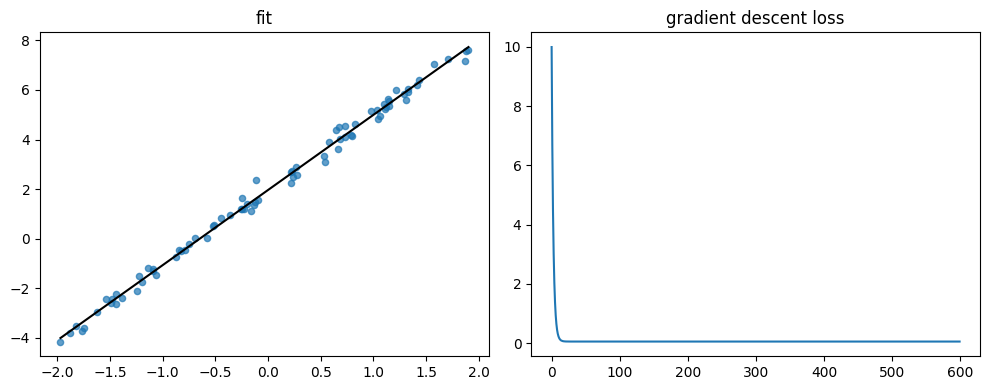

In [4]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# 左图展示散点和拟合直线，直观看模型是否抓住线性趋势。
plt.scatter(X[:,0], y, s=20, alpha=0.7)
xs = np.linspace(X.min(), X.max(), 100)
plt.plot(xs, theta_closed[0] + theta_closed[1] * xs, color='black')
plt.title('fit')
plt.subplot(1, 2, 2)
# 右图展示训练过程中损失是否持续下降。
plt.plot(loss_history)
plt.title('gradient descent loss')
plt.tight_layout(); plt.show()
